# Student Performance Prediction System
## Decision Tree Classification: Pass vs Fail

This notebook trains a Decision Tree classifier to predict whether a student will **pass or fail** based on:
- Socioeconomic Score
- Study Hours
- Sleep Hours
- Attendance (%)

Target: `Grades >= 50` → **Pass (1)**, else **Fail (0)**

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('All imports successful!')

All imports successful!


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('../data/data.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplicates: {df.duplicated().sum()}')
df.head(10)

Dataset shape: (1388, 5)

Column types:
Socioeconomic Score    float64
Study Hours            float64
Sleep Hours            float64
Attendance (%)         float64
Grades                 float64
dtype: object

Missing values:
Socioeconomic Score    0
Study Hours            0
Sleep Hours            0
Attendance (%)         0
Grades                 0
dtype: int64

Duplicates: 0


,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0
5,0.98320,3.4,9.0,47.0,51.0
6,0.56648,7.9,8.1,63.0,54.0
7,0.93487,1.4,8.0,47.0,34.0
8,0.46660,5.4,8.8,67.0,39.0
9,0.62130,1.4,9.6,42.0,34.0


In [3]:
df.describe().round(3)

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
count,1388.000,1388.000,1388.000,1388.000,1388.000
mean,0.552,4.561,8.047,58.536,40.692
std,0.261,1.898,1.371,11.675,9.467
min,0.101,0.800,4.800,40.000,32.000
25%,0.322,3.475,7.000,49.000,34.000
50%,0.546,3.900,8.400,57.000,35.000
75%,0.790,5.900,9.100,66.000,47.000
max,1.000,10.000,10.000,100.000,91.000


## 3. Exploratory Data Analysis (EDA)

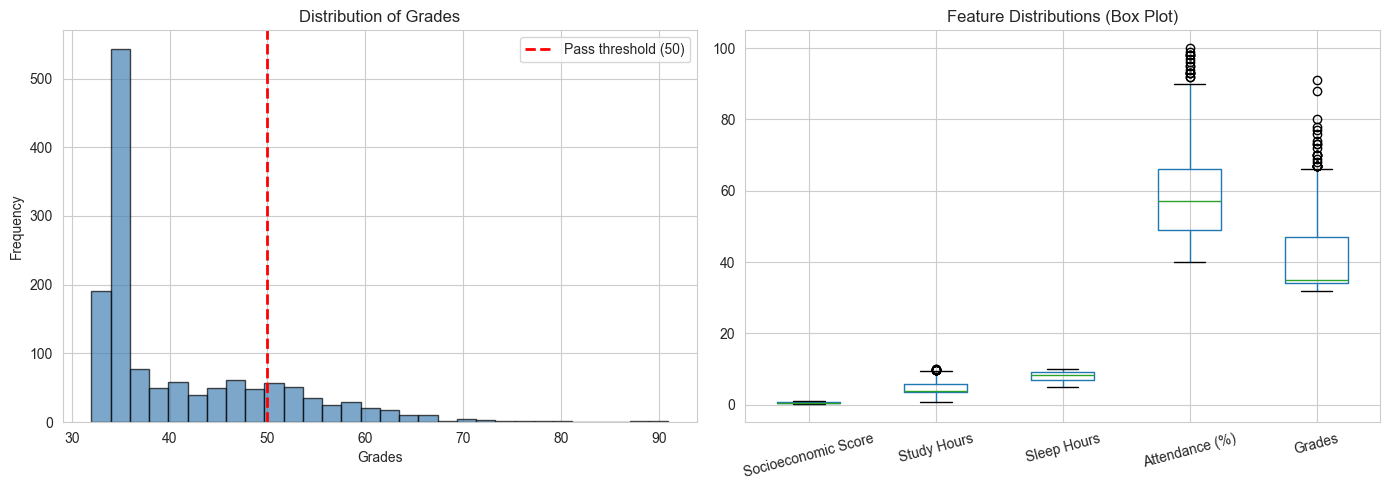

In [4]:
# Distribution of Grades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Grades'], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Pass threshold (50)')
axes[0].set_xlabel('Grades')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Grades')
axes[0].legend()

# Box plot of all features
df.boxplot(ax=axes[1])
axes[1].set_title('Feature Distributions (Box Plot)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

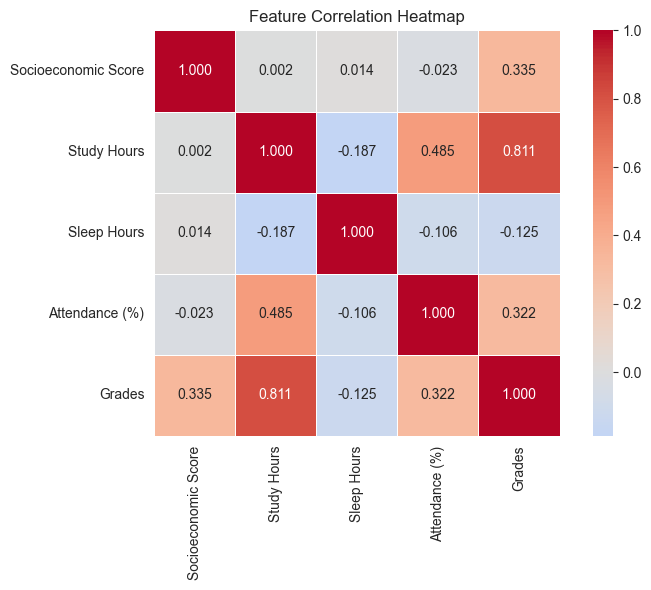

In [5]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

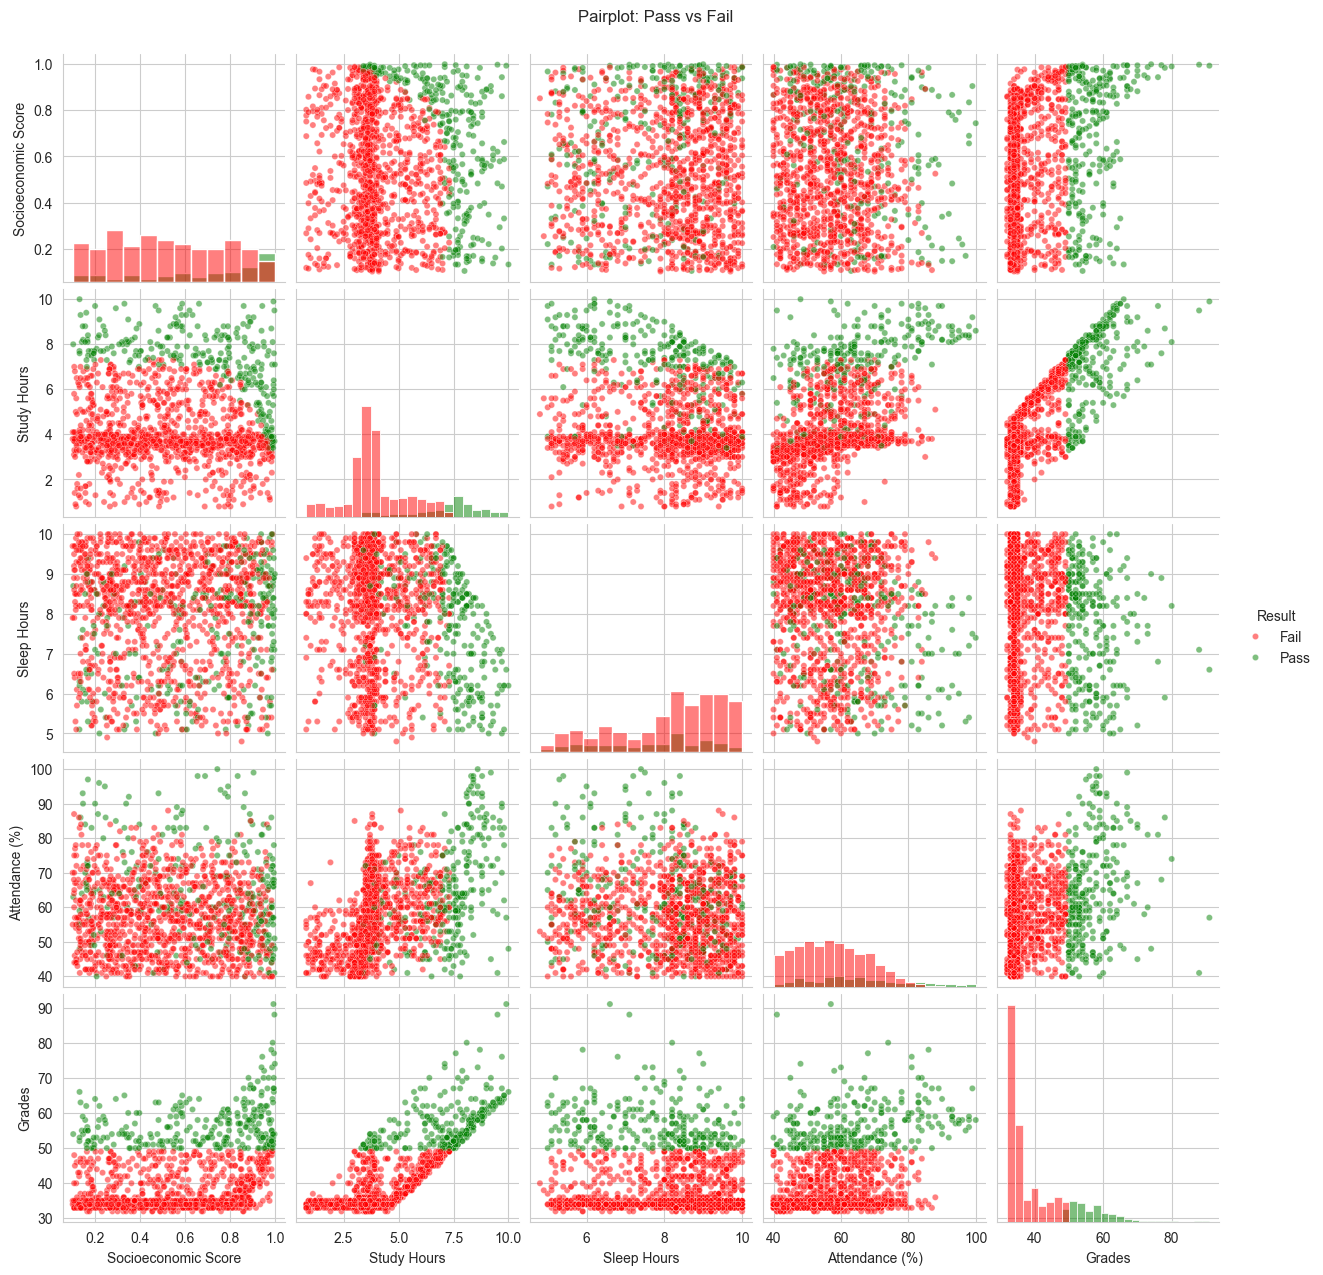

In [6]:
# Pairplot colored by pass/fail
df_temp = df.copy()
df_temp['Result'] = np.where(df_temp['Grades'] >= 50, 'Pass', 'Fail')
sns.pairplot(df_temp, hue='Result', palette={'Pass': 'green', 'Fail': 'red'}, 
             diag_kind='hist', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot: Pass vs Fail', y=1.02)
plt.show()
df_temp.drop(columns='Result', inplace=True)

## 4. Feature Engineering & Target Creation

Pass/Fail distribution:
Pass
0    1116
1     272
Name: count, dtype: int64

Pass rate: 19.6%


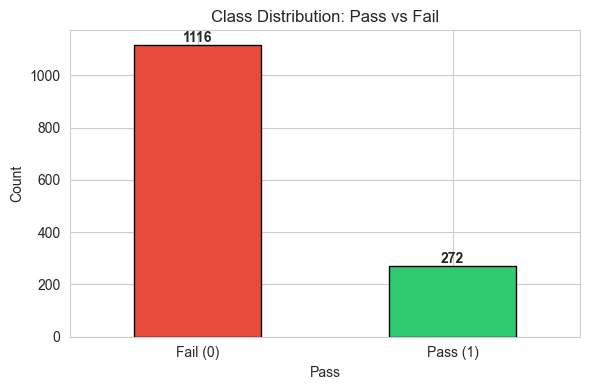

In [7]:
# Create binary target: Pass (1) if Grades >= 50, else Fail (0)
PASS_THRESHOLD = 50
df['Pass'] = (df['Grades'] >= PASS_THRESHOLD).astype(int)

print(f'Pass/Fail distribution:')
print(df['Pass'].value_counts())
print(f'\nPass rate: {df["Pass"].mean() * 100:.1f}%')

# Visualize class balance
fig, ax = plt.subplots(figsize=(6, 4))
df['Pass'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black', ax=ax)
ax.set_xticklabels(['Fail (0)', 'Pass (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Class Distribution: Pass vs Fail')
for i, v in enumerate(df['Pass'].value_counts()):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Engineered features for better accuracy
df['Study_x_Attendance'] = df['Study Hours'] * df['Attendance (%)']
df['Study_x_Socioeconomic'] = df['Study Hours'] * df['Socioeconomic Score']
df['Attendance_x_Socioeconomic'] = df['Attendance (%)'] * df['Socioeconomic Score']
df['Study_sq'] = df['Study Hours'] ** 2

print('Engineered features added.')
df.head()

Engineered features added.


,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades,Pass,Study_x_Attendance,Study_x_Socioeconomic,Attendance_x_Socioeconomic,Study_sq
0,0.95822,3.4,8.2,53.0,47.0,0,180.2,3.257948,50.78566,11.56
1,0.85566,3.2,5.9,55.0,35.0,0,176.0,2.738112,47.06130,10.24
2,0.68025,3.2,9.3,41.0,32.0,0,131.2,2.176800,27.89025,10.24
3,0.25936,3.2,8.2,47.0,34.0,0,150.4,0.829952,12.18992,10.24
4,0.60447,3.8,10.0,75.0,33.0,0,285.0,2.296986,45.33525,14.44


## 5. Prepare Features & Split Data

In [9]:
# Features (drop Grades and target)
FEATURE_COLS = [
    'Socioeconomic Score', 'Study Hours', 'Sleep Hours', 'Attendance (%)',
    'Study_x_Attendance', 'Study_x_Socioeconomic',
    'Attendance_x_Socioeconomic', 'Study_sq'
]

X = df[FEATURE_COLS]
y = df['Pass']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns: {FEATURE_COLS}')

Features shape: (1388, 8)
Target shape: (1388,)

Feature columns: ['Socioeconomic Score', 'Study Hours', 'Sleep Hours', 'Attendance (%)', 'Study_x_Attendance', 'Study_x_Socioeconomic', 'Attendance_x_Socioeconomic', 'Study_sq']


In [10]:
# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTrain pass rate: {y_train.mean():.3f}')
print(f'Test pass rate:  {y_test.mean():.3f}')

Training set: 1110 samples
Test set:     278 samples

Train pass rate: 0.196
Test pass rate:  0.194


## 6. Baseline Decision Tree

In [11]:
# Train a baseline (default) decision tree
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

y_pred_baseline = dt_baseline.predict(X_test)

print('=== Baseline Decision Tree ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_baseline):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_baseline):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}')
print(f'\nTree depth: {dt_baseline.get_depth()}')
print(f'Number of leaves: {dt_baseline.get_n_leaves()}')

=== Baseline Decision Tree ===
Accuracy:  0.9712
Precision: 0.9107
Recall:    0.9444
F1 Score:  0.9273

Tree depth: 10
Number of leaves: 26


## 7. Hyperparameter Tuning with GridSearchCV

In [12]:
# Extensive grid search for best decision tree
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15, None],
    'min_samples_split': [2, 3, 5, 7, 10, 15, 20],
    'min_samples_leaf': [1, 2, 3, 5, 7, 10, 15],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None],
    'splitter': ['best', 'random'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print('Running GridSearchCV... (this may take a minute)')
grid_search.fit(X_train, y_train)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV F1 score: {grid_search.best_score_:.4f}')

Running GridSearchCV... (this may take a minute)
Fitting 5 folds for each of 5880 candidates, totalling 29400 fits

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 10, 'splitter': 'random'}
Best CV F1 score: 0.9280


In [13]:
# Evaluate the best model on test set
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
y_proba = best_dt.predict_proba(X_test)[:, 1]

print('=== Tuned Decision Tree (Test Set) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}')
print(f'\nTree depth: {best_dt.get_depth()}')
print(f'Number of leaves: {best_dt.get_n_leaves()}')

=== Tuned Decision Tree (Test Set) ===
Accuracy:  0.9676
Precision: 0.9412
Recall:    0.8889
F1 Score:  0.9143
ROC AUC:   0.9770

Tree depth: 10
Number of leaves: 28


In [14]:
# Cross-validation scores on full training data
cv_scores = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'5-Fold CV F1 Scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

cv_acc = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring='accuracy')
print(f'\n5-Fold CV Accuracy: {cv_acc.round(4)}')
print(f'Mean: {cv_acc.mean():.4f} (+/- {cv_acc.std() * 2:.4f})')

5-Fold CV F1 Scores: [0.9195 0.9213 0.9565 0.9885 0.8539]
Mean: 0.9280 (+/- 0.0898)

5-Fold CV Accuracy: [0.9685 0.9685 0.982  0.9955 0.9414]
Mean: 0.9712 (+/- 0.0359)


## 8. Detailed Evaluation

In [15]:
# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

Classification Report:
              precision    recall  f1-score   support

        Fail       0.97      0.99      0.98       224
        Pass       0.94      0.89      0.91        54

    accuracy                           0.97       278
   macro avg       0.96      0.94      0.95       278
weighted avg       0.97      0.97      0.97       278



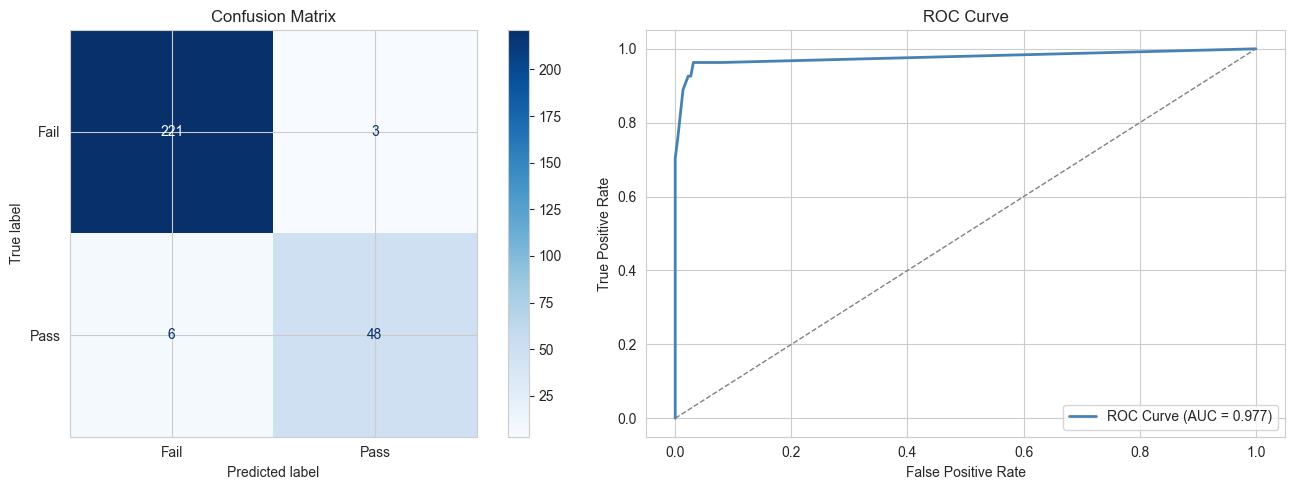

In [16]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Fail', 'Pass'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

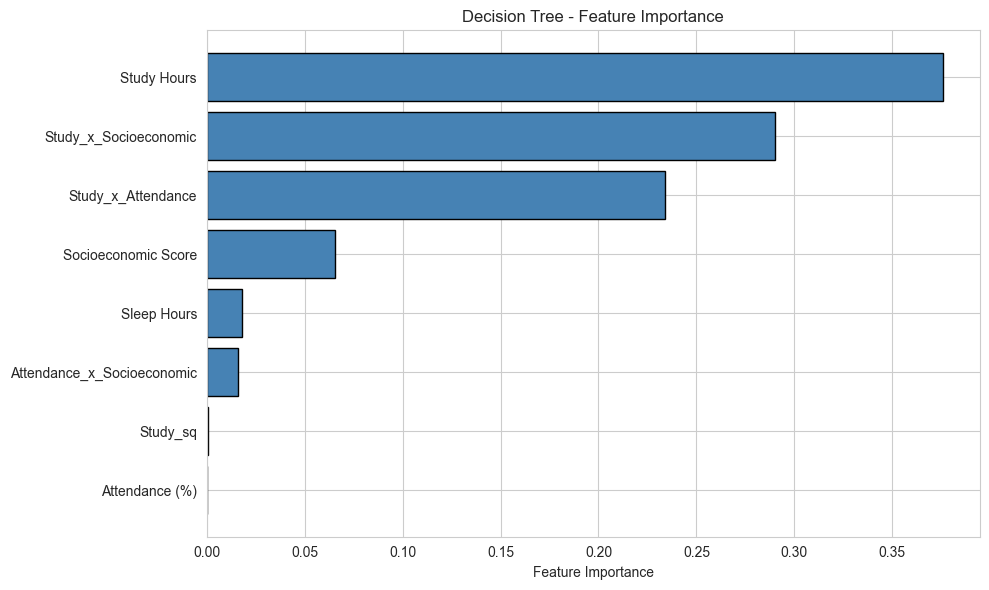

                   Feature  Importance
               Study Hours    0.375991
     Study_x_Socioeconomic    0.290100
        Study_x_Attendance    0.234151
       Socioeconomic Score    0.065250
               Sleep Hours    0.017811
Attendance_x_Socioeconomic    0.015890
                  Study_sq    0.000806
            Attendance (%)    0.000000


In [17]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Feature Importance')
plt.title('Decision Tree - Feature Importance')
plt.tight_layout()
plt.show()

print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

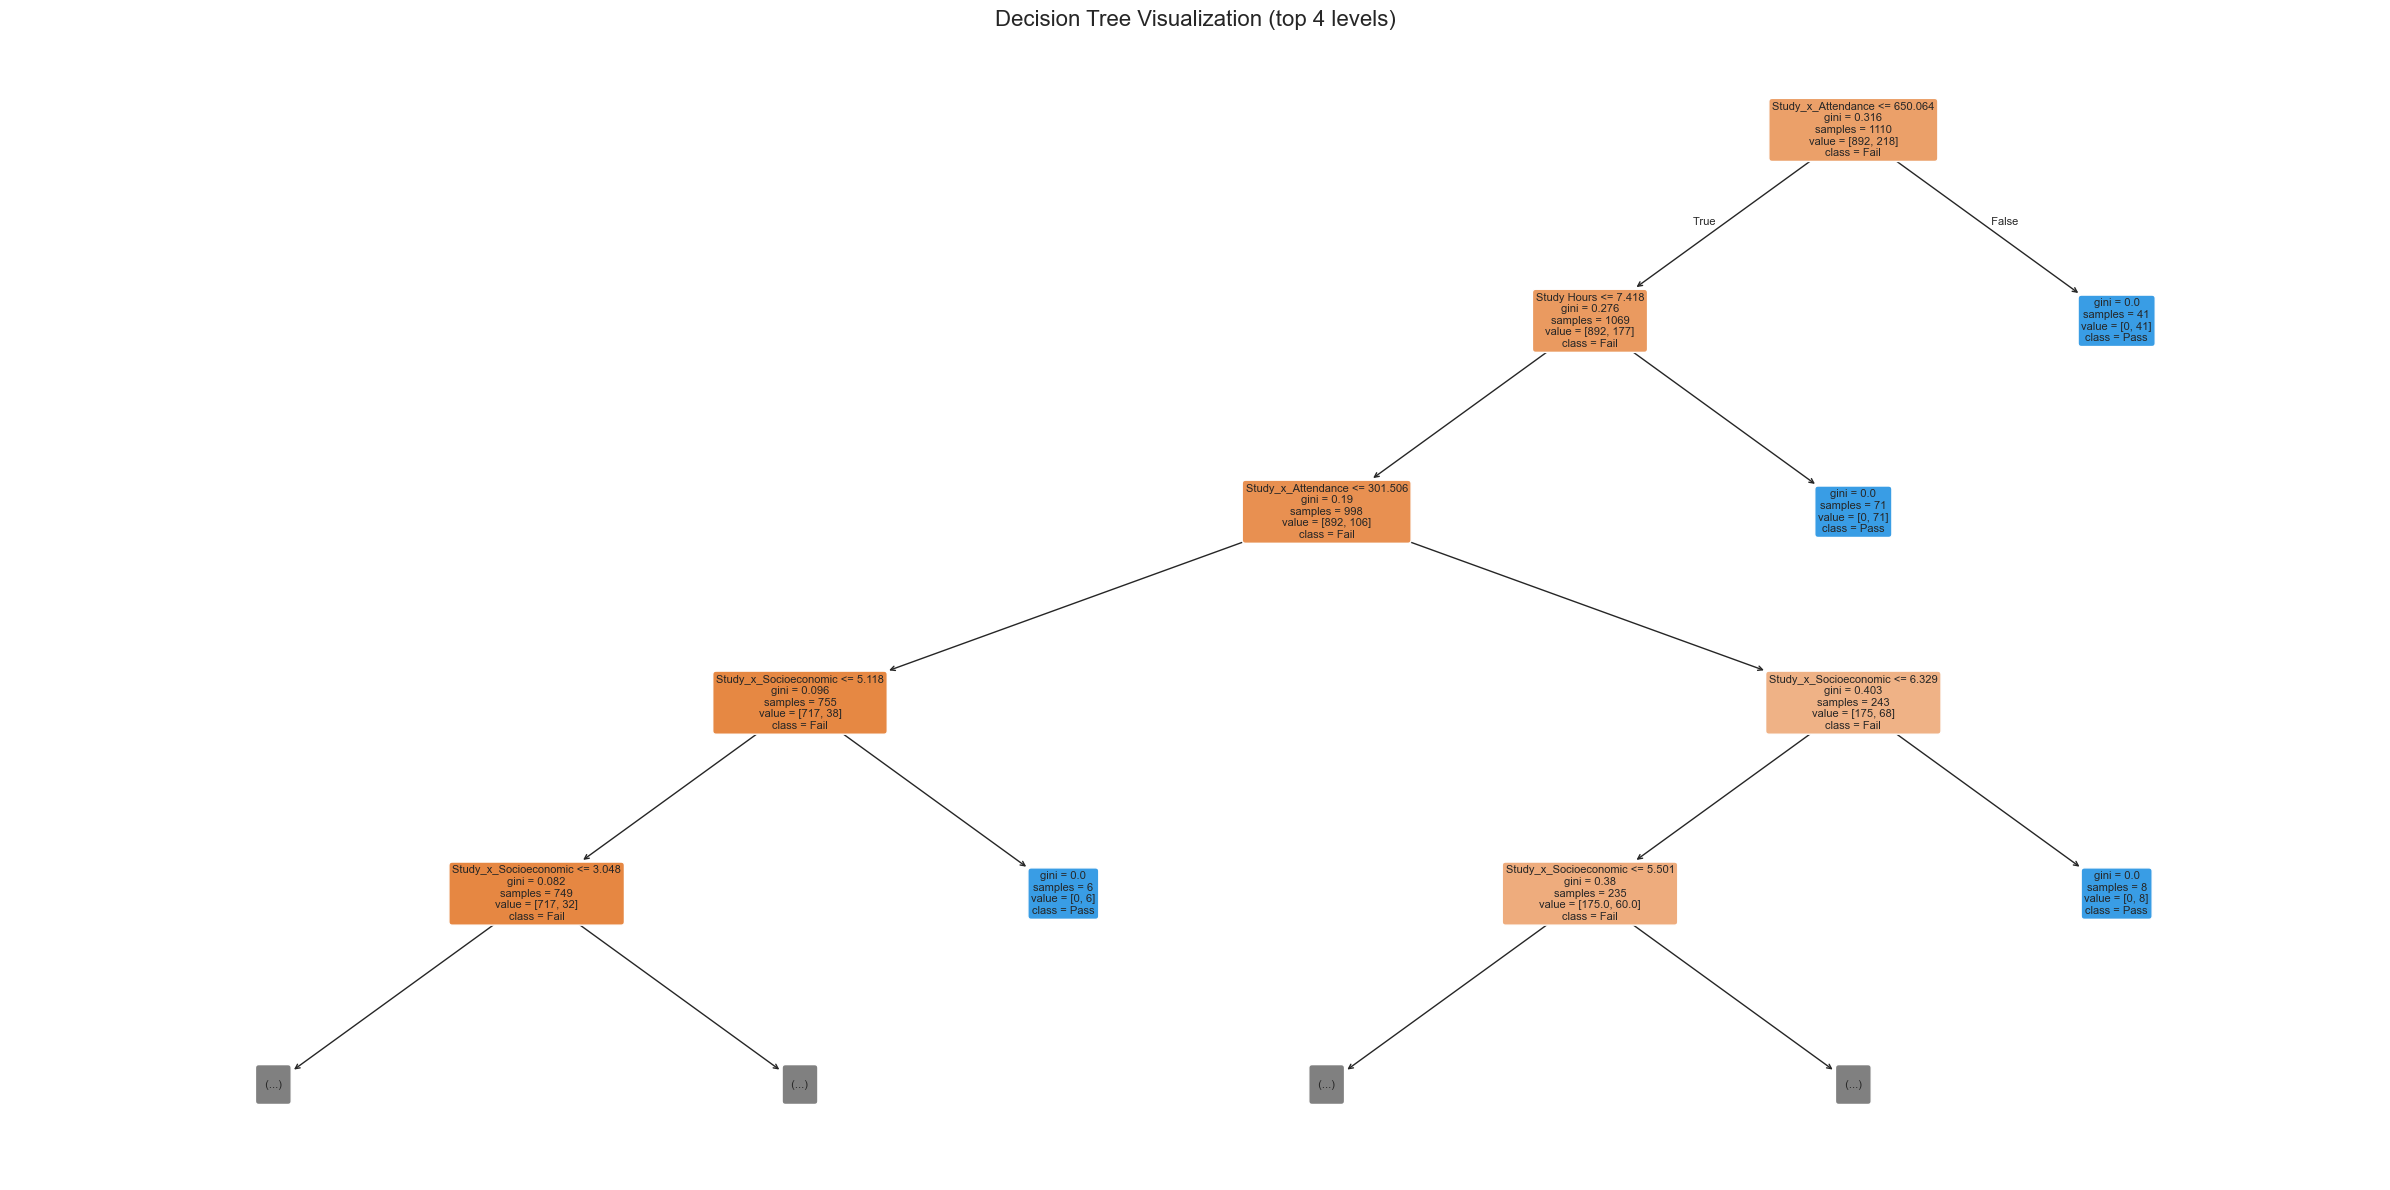

In [18]:
# Visualize the Decision Tree
plt.figure(figsize=(24, 12))
plot_tree(
    best_dt, 
    feature_names=FEATURE_COLS,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4  # limit display depth for readability
)
plt.title('Decision Tree Visualization (top 4 levels)', fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
# Text representation of the tree (first few levels)
tree_rules = export_text(best_dt, feature_names=FEATURE_COLS, max_depth=4)
print('Decision Rules (top 4 levels):')
print(tree_rules)

Decision Rules (top 4 levels):
|--- Study_x_Attendance <= 650.06
|   |--- Study Hours <= 7.42
|   |   |--- Study_x_Attendance <= 301.51
|   |   |   |--- Study_x_Socioeconomic <= 5.12
|   |   |   |   |--- Study_x_Socioeconomic <= 3.05
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Study_x_Socioeconomic >  3.05
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Study_x_Socioeconomic >  5.12
|   |   |   |   |--- class: 1
|   |   |--- Study_x_Attendance >  301.51
|   |   |   |--- Study_x_Socioeconomic <= 6.33
|   |   |   |   |--- Study_x_Socioeconomic <= 5.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- Study_x_Socioeconomic >  5.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Study_x_Socioeconomic >  6.33
|   |   |   |   |--- class: 1
|   |--- Study Hours >  7.42
|   |   |--- class: 1
|--- Study_x_Attendance >  650.06
|   |--- class: 1



## 9. Save the Model & Metadata

In [20]:
# Save model and metadata
model_artifact = {
    'model': best_dt,
    'feature_columns': FEATURE_COLS,
    'pass_threshold': PASS_THRESHOLD,
    'best_params': grid_search.best_params_,
    'test_accuracy': accuracy_score(y_test, y_pred),
    'test_f1': f1_score(y_test, y_pred),
    'test_roc_auc': roc_auc_score(y_test, y_proba),
}

model_path = '../models/student_performance_model.joblib'
joblib.dump(model_artifact, model_path)

print(f'Model saved to: {model_path}')
print(f'\nSaved artifact keys: {list(model_artifact.keys())}')
print(f'Test Accuracy: {model_artifact["test_accuracy"]:.4f}')
print(f'Test F1:       {model_artifact["test_f1"]:.4f}')
print(f'Test ROC AUC:  {model_artifact["test_roc_auc"]:.4f}')

Model saved to: ../models/student_performance_model.joblib

Saved artifact keys: ['model', 'feature_columns', 'pass_threshold', 'best_params', 'test_accuracy', 'test_f1', 'test_roc_auc']
Test Accuracy: 0.9676
Test F1:       0.9143
Test ROC AUC:  0.9770


In [21]:
# Verify the saved model loads correctly
loaded = joblib.load(model_path)
loaded_model = loaded['model']
test_pred = loaded_model.predict(X_test)
print(f'Loaded model accuracy: {accuracy_score(y_test, test_pred):.4f}')
print('Model save/load verification: PASSED')

Loaded model accuracy: 0.9676
Model save/load verification: PASSED


## 10. Quick Prediction Demo

In [22]:
# Demo: Predict for a sample student
def predict_student(socioeconomic, study_hours, sleep_hours, attendance):
    """Predict pass/fail for a single student."""
    features = {
        'Socioeconomic Score': socioeconomic,
        'Study Hours': study_hours,
        'Sleep Hours': sleep_hours,
        'Attendance (%)': attendance,
        'Study_x_Attendance': study_hours * attendance,
        'Study_x_Socioeconomic': study_hours * socioeconomic,
        'Attendance_x_Socioeconomic': attendance * socioeconomic,
        'Study_sq': study_hours ** 2,
    }
    input_df = pd.DataFrame([features])
    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0]
    
    result = 'PASS' if prediction == 1 else 'FAIL'
    print(f'Prediction: {result}')
    print(f'Confidence: Fail={probability[0]:.1%}, Pass={probability[1]:.1%}')
    return result, probability

print('--- High-performing student ---')
predict_student(0.8, 8.0, 7.5, 85)

print('\n--- Low-performing student ---')
predict_student(0.3, 2.0, 6.0, 40)

--- High-performing student ---
Prediction: PASS
Confidence: Fail=0.0%, Pass=100.0%

--- Low-performing student ---
Prediction: FAIL
Confidence: Fail=100.0%, Pass=0.0%


('FAIL', array([1., 0.]))